This routine generates **Figure 4** and its supplementary panels. If you have any questions please contact [a.sarfraz@uu.nl](mailto:a.sarfraz@uu.nl).


### Imports

In [8]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

### Setting directories

In [9]:
from __future__ import annotations

import sys
from pathlib import Path

import yaml

_NB_DIR   = Path.cwd()
REPO_ROOT = _NB_DIR.parent if _NB_DIR.name == "notebooks" else _NB_DIR

sys.path.insert(0, str(REPO_ROOT / "src"))

_cfg = yaml.safe_load((REPO_ROOT / "config" / "paths.yaml").read_text())

def _resolve(p):
    p = Path(p)
    return p if p.is_absolute() else (REPO_ROOT / p).resolve()

PATHS = {
    "data":    {k: _resolve(v) for k, v in _cfg["data"].items()},
    "outputs": {k: _resolve(v) for k, v in _cfg["outputs"].items()},
}

from potable_reuse.style import apply_style
apply_style()

DATA_DIR = PATHS["data"]["regional_reductions_dir"]
FIG_DIR  = PATHS["outputs"]["figure4"]
FIG_DIR.mkdir(parents=True, exist_ok=True)

### Loading cached data

Each `regional_reductions_PR{n}.parquet` file holds, for every (region, year, scenario) cell, the regional municipal water withdrawal without reuse (`muni_pr0`) and with reuse (`muni_prx`), and the percentage reduction between them. Figure 4 uses PR100.

In [10]:
def load_regional_reductions(pr_label):
    """Load the regional-reduction parquet for one PR level."""
    path = DATA_DIR / f"regional_reductions_{pr_label}.parquet"
    if not path.exists():
        raise FileNotFoundError(path)
    df = pd.read_parquet(path)
    df = df[df["pct_reduction"].notna()]
    return df


raw_pr100 = load_regional_reductions("PR100")

print(f"PR100 : {len(raw_pr100):,} rows | "
      f"{raw_pr100['region'].nunique()} regions")

PR100 : 78,336 rows | 32 regions


### Constants and helpers

Year window, the four exemplar regions and the figure export.

In [11]:
START_YEAR = 2025
END_YEAR   = 2100

TARGET_REGIONS = [
    ("United States", ["USA", "United States"]),
    ("Middle East",   ["Middle East"]),
    ("Pakistan",      ["Pakistan"]),
    ("Japan",         ["Japan"]),
]


def _norm(s):
    return s.lower().replace("_", "").replace(" ", "")


def match_region(candidates, available):
    """Resolve a region label against the parquet's actual labels.
    Tries exact normalised match first, then substring fallback.
    Returns the canonical label found in `available`, or None."""
    norm = {_norm(r): r for r in available}
    for c in candidates:
        if _norm(c) in norm:
            return norm[_norm(c)]
    for c in candidates:
        nc = _norm(c)
        for k, v in norm.items():
            if nc in k or k in nc:
                return v
    return None


def save_all(fig, out_dir, stem, dpi=300):
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_dir / f"{stem}.png", dpi=dpi, bbox_inches="tight")
    # fig.savefig(out_dir / f"{stem}.svg", bbox_inches="tight")
    # svg = (out_dir / f"{stem}.svg").read_text(encoding="utf-8")
    # (out_dir / f"{stem}.html").write_text(
    #     f"<!doctype html><meta charset='utf-8'><title>{stem}</title>"
    #     f"<body style='margin:0;padding:1rem;font-family:system-ui'>{svg}</body>",
    #     encoding="utf-8",
    # )

### Figure 4

Municipal water withdrawal in the four exemplar regions: no reuse (PR0) against maximum reuse (PR100) by reuse extraction cost. Bands are the 5th to 95th percentile across scenarios.

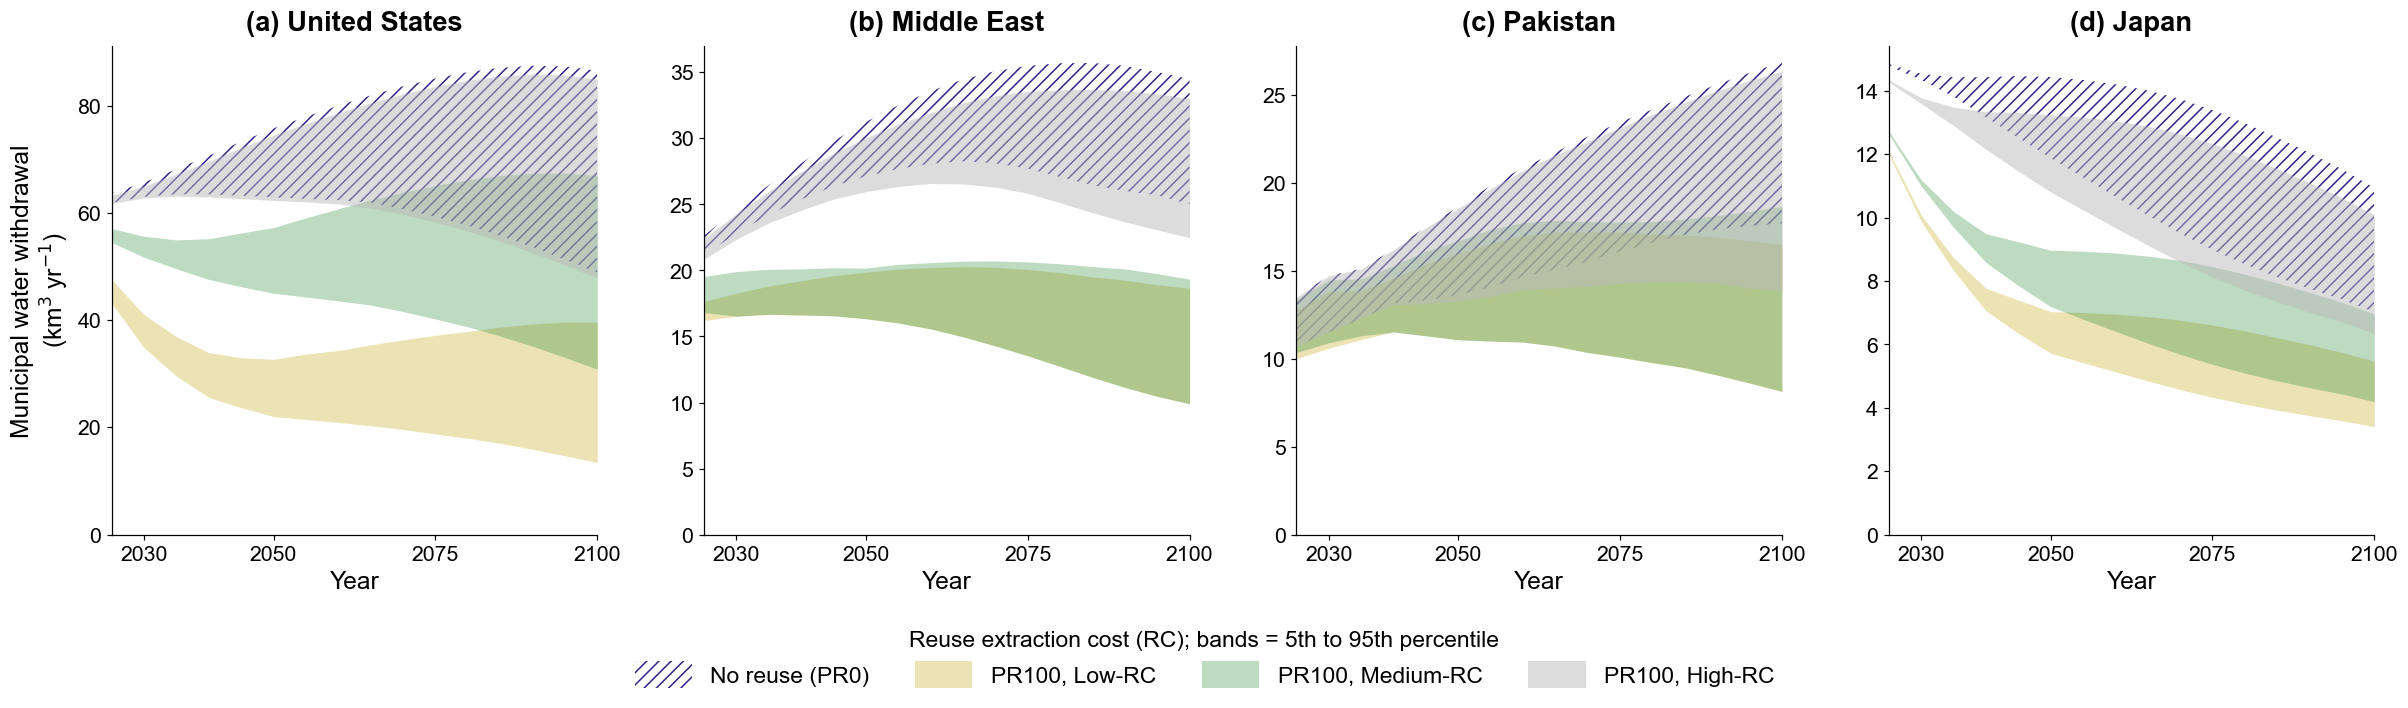

In [12]:
# FIGURE 4: municipal water withdrawal, 4 exemplar regions.
# Grey = no reuse (PR0); colored = maximum reuse (PR100) stratified by
# reuse cost. Each band = 5th-95th percentile across scenarios.
# Low and high cost are solid shading; medium cost is hatched so the
# overlaps between the bands stay readable.
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# (label, color, alpha, hatch). Paul Tol colors, light -> dark, colorblind-safe.
# PR0 = ("No reuse (PR0)", "black", 0.30, None)
# COST = {"LRC": ("Low-RC",    "#DDCC77", 0.55, None),
#         "MRC": ("Medium-RC", "#228833", 0.00, "///"),
#         "HRC": ("High-RC",   "#332288", 0.30, None)}

PR0 = ("No reuse (PR0)", "#332288", 0.00, "///")          # lighter grey
COST = {"LRC": ("Low-RC",    "#DDCC77", 0.55, None),
        "MRC": ("Medium-RC", "#228833", 0.30, None),     # now solid
        "HRC": ("High-RC",   "#BBBBBB", 0.5, None)}    #
PR0_EDGE = "#555555"
plt.rcParams["hatch.linewidth"] = 1.0

df = raw_pr100[raw_pr100["year"].between(START_YEAR, END_YEAR)].copy()
df[["muni_pr0", "muni_prx"]] = df[["muni_pr0", "muni_prx"]].apply(pd.to_numeric)
available = df["region"].unique()

def band(ax, s, color, alpha, hatch):
    """5th-95th percentile band: solid fill, or hatch pattern if given."""
    x, lo, hi = s.median().index, s.quantile(0.05), s.quantile(0.95)
    if hatch:
        ax.fill_between(x, lo, hi, facecolor="none", edgecolor=color,
                        hatch=hatch, linewidth=0)
    else:
        ax.fill_between(x, lo, hi, color=color, alpha=alpha, linewidth=0)

fig, axes = plt.subplots(1, 4, figsize=(22, 5.6))

for ax, letter, (label, candidates) in zip(axes, "abcd", TARGET_REGIONS):
    reg = df[df["region"] == match_region(candidates, available)]
    p0 = reg.groupby("year")["muni_pr0"]

    # No-reuse band first, so it sits behind the cost bands
    band(ax, p0, *PR0[1:])

    for cost, (_, color, alpha, hatch) in COST.items():
        band(ax, reg[reg["reuse_cost"] == cost].groupby("year")["muni_prx"],
             color, alpha, hatch)



    ax.set_title(f"({letter}) {label}", fontweight="bold", fontsize=18, pad=10)
    ax.set_xlabel("Year", fontsize=16)
    ax.set_xlim(START_YEAR, END_YEAR)
    ax.set_xticks([2030, 2050, 2075, 2100])
    ax.set_ylim(bottom=0)
    ax.tick_params(labelsize=14)

axes[0].set_ylabel("Municipal water withdrawal\n(km$^3$ yr$^{-1}$)", fontsize=16)


def legend_patch(label, color, alpha, hatch):
    """Legend swatch that matches band(): hatch pattern if given, else solid fill."""
    if hatch:
        return Patch(facecolor="none", edgecolor=color, hatch=hatch,
                     linewidth=0, label=label)
    return Patch(facecolor=color, alpha=alpha, edgecolor="none", label=label)

handles = [legend_patch(*PR0)]
handles += [legend_patch(f"PR100, {l}", c, a, h) for l, c, a, h in COST.values()]

fig.legend(handles=handles,
           title="Reuse extraction cost (RC); bands = 5th to 95th percentile",
           loc="lower center", ncol=4, frameon=False, fontsize=15,
           title_fontsize=15, handlelength=2.5, handleheight=1.4,
           bbox_to_anchor=(0.5, -0.16))

fig.tight_layout()
fig.subplots_adjust(wspace=0.22)
save_all(fig, FIG_DIR, "Figure4")
plt.show()
plt.close(fig)

### Supplementary: all regions

The same comparison for every region on one page.

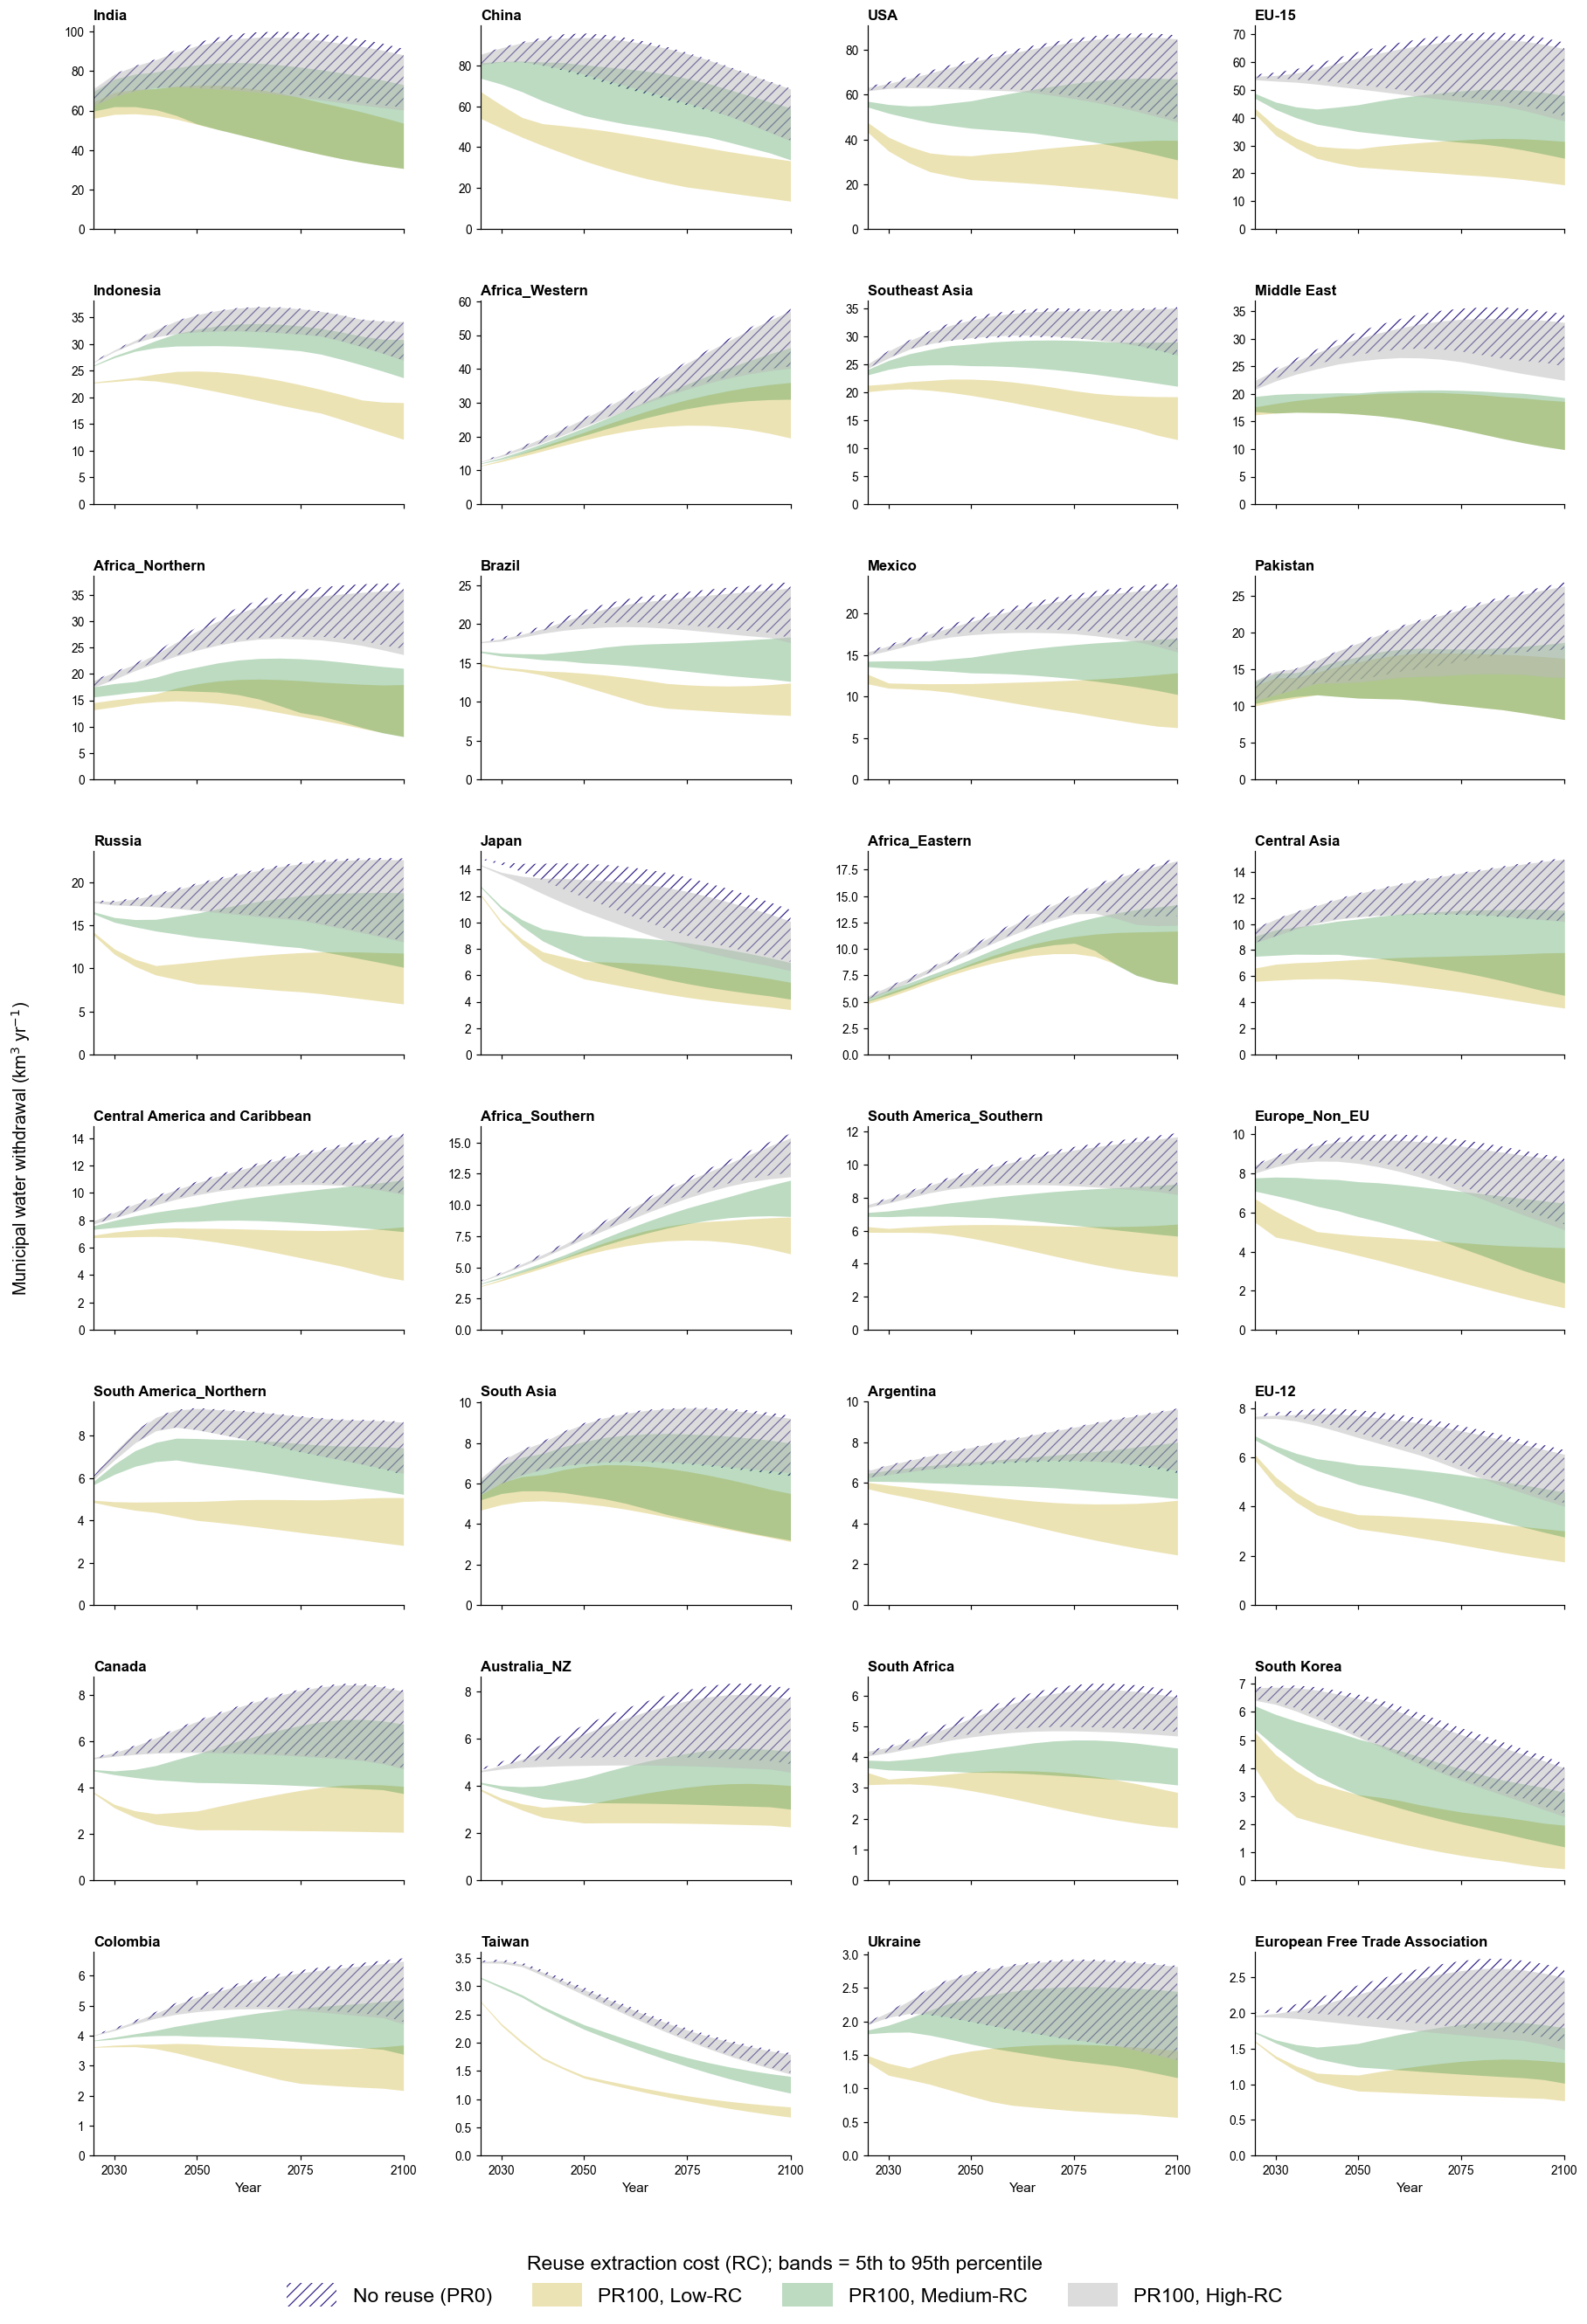

In [13]:
# FIGURE 4 (all regions): municipal water withdrawal, one page, small multiples.
# Grey = no reuse (PR0); colored = maximum reuse (PR100) stratified by reuse cost.
# Each band = 5th-95th percentile across scenarios.
# Low and medium cost are solid shading; high cost is hatched.
# Relies on objects from your notebook: raw_pr100, START_YEAR, END_YEAR,
# FIG_DIR, save_all.
import math
import string
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---------------------------------------------------------------- styling ---
PR0 = ("No reuse (PR0)", "#332288", 0.00, "///")          # lighter grey
COST = {"LRC": ("Low-RC",    "#DDCC77", 0.55, None),
        "MRC": ("Medium-RC", "#228833", 0.30, None),     # now solid
        "HRC": ("High-RC",   "#BBBBBB", 0.5, None)}    #
plt.rcParams["hatch.linewidth"] = 0.8

# Layout: page-shaped figure (A4-ish portrait scaled up). Tune NCOLS if needed.
NCOLS = 4
PANEL_W, PANEL_H = 4.2, 3.0          # inches per panel
SORT_BY_SIZE = True                  # order panels by median PR0 withdrawal
REGION_LABELS = {}                   # optional {"raw_name": "Pretty name"}

# ------------------------------------------------------------------- data ---
df = raw_pr100[raw_pr100["year"].between(START_YEAR, END_YEAR)].copy()
df[["muni_pr0", "muni_prx"]] = df[["muni_pr0", "muni_prx"]].apply(pd.to_numeric)

regions = list(df["region"].dropna().unique())
if SORT_BY_SIZE:
    size = df.groupby("region")["muni_pr0"].median()
    regions = sorted(regions, key=lambda r: -size.get(r, 0))
else:
    regions = sorted(regions)


def panel_letters(n):
    """a, b, ..., z, aa, ab, ... for any number of panels."""
    abc = string.ascii_lowercase
    out = []
    for i in range(n):
        s, k = "", i
        while True:
            s = abc[k % 26] + s
            k = k // 26 - 1
            if k < 0:
                break
        out.append(s)
    return out


def band(ax, s, color, alpha, hatch):
    """5th-95th percentile band: solid fill, or hatch pattern if given."""
    lo, hi = s.quantile(0.05), s.quantile(0.95)
    if lo.empty:
        return
    x = lo.index
    if hatch:
        ax.fill_between(x, lo, hi, facecolor="none", edgecolor=color,
                        hatch=hatch, linewidth=0)
    else:
        ax.fill_between(x, lo, hi, color=color, alpha=alpha, linewidth=0)


# ------------------------------------------------------------------- plot ---
n = len(regions)
nrows = math.ceil(n / NCOLS)
fig, axes = plt.subplots(nrows, NCOLS,
                         figsize=(NCOLS * PANEL_W, nrows * PANEL_H),
                         squeeze=False)
flat = axes.ravel()

for i, (ax, letter, region) in enumerate(zip(flat, panel_letters(n), regions)):
    reg = df[df["region"] == region]

    band(ax, reg.groupby("year")["muni_pr0"], *PR0[1:])      # PR0 behind
    for cost, (_, color, alpha, hatch) in COST.items():
        band(ax, reg[reg["reuse_cost"] == cost].groupby("year")["muni_prx"],
             color, alpha, hatch)

    label = REGION_LABELS.get(region, region)
    ax.set_title(label, fontweight="bold", fontsize=11,
                 loc="left", pad=4)
    ax.set_xlim(START_YEAR, END_YEAR)
    ax.set_xticks([2030, 2050, 2075, 2100])
    ax.set_ylim(bottom=0)
    ax.tick_params(labelsize=9)
    ax.spines[["top", "right"]].set_visible(False)

    row, col = divmod(i, NCOLS)
    last_in_col = (row == nrows - 1) or (i + NCOLS >= n)
    if not last_in_col:
        ax.set_xticklabels([])          # x labels only on bottom panel per column
    else:
        ax.set_xlabel("Year", fontsize=10)

for ax in flat[n:]:                     # hide unused grid cells
    ax.set_visible(False)

fig.supylabel("Municipal water withdrawal (km$^3$ yr$^{-1}$)", fontsize=13)


def legend_patch(label, color, alpha, hatch):
    """Legend swatch that matches band(): hatch pattern if given, else solid fill."""
    if hatch:
        return Patch(facecolor="none", edgecolor=color, hatch=hatch,
                     linewidth=0, label=label)
    return Patch(facecolor=color, alpha=alpha, edgecolor="none", label=label)

handles = [legend_patch(*PR0)]
handles += [legend_patch(f"PR100, {l}", c, a, h) for l, c, a, h in COST.values()]
fig.tight_layout(rect=(0.02, 0.04, 1, 1))
fig.subplots_adjust(hspace=0.35, wspace=0.25)
fig.legend(handles=handles,
           title="Reuse extraction cost (RC); bands = 5th to 95th percentile",
           loc="lower center", ncol=4, frameon=False, fontsize=15,
           title_fontsize=15, handlelength=2.5, handleheight=1.4,
           bbox_to_anchor=(0.5, -0.01))




# handles = [Patch(facecolor=PR0[1], alpha=PR0[2], edgecolor="none", label=PR0[0])]
# handles += [Patch(facecolor="none", edgecolor=c, hatch=h, label=f"PR100, {l}") if h
#             else Patch(facecolor=c, alpha=a, edgecolor="none", label=f"PR100, {l}")
#             for l, c, a, h in COST.values()]

# fig.tight_layout(rect=(0.02, 0.04, 1, 1))
# fig.subplots_adjust(hspace=0.35, wspace=0.25)
# fig.legend(handles=handles,
#            title="Reuse extraction cost (RC); bands = 5th–95th percentile",
#            loc="lower center", ncol=4, frameon=False, fontsize=11,
#            title_fontsize=11, handlelength=2.5, handleheight=1.2,
#            bbox_to_anchor=(0.5, -0.01))

save_all(fig, FIG_DIR, "SI_fig4_PR0_PR100_by_cost_all_regions")
plt.show()
plt.close(fig)

### Supplementary: regional trajectories, all regions

In [ ]:
# # Regional trajectories for all regions (PR100 and PR50): one panel per
# # region with the ensemble median and the IQR and 5th to 95th percentile
# # bands. Uncomment to run.

# raw_pr50 = load_regional_reductions("PR50")


# def ensemble_stats(df, start_year=START_YEAR, end_year=END_YEAR):
#     """Per (region, year) ensemble statistics on `pct_reduction`.

#     Returns the median, mean, the 5th, 25th, 75th and 95th percentiles, the
#     observed minimum and maximum, and the member count `n` behind each
#     estimate. Percentiles use the pandas default (linear interpolation).
#     """
#     df = df[(df["year"] >= start_year) & (df["year"] <= end_year)]
#     return (df.groupby(["region", "year"], as_index=False)
#               .agg(median=("pct_reduction", "median"),
#                    mean=("pct_reduction", "mean"),
#                    q05=("pct_reduction", lambda s: s.quantile(0.05)),
#                    q25=("pct_reduction", lambda s: s.quantile(0.25)),
#                    q75=("pct_reduction", lambda s: s.quantile(0.75)),
#                    q95=("pct_reduction", lambda s: s.quantile(0.95)),
#                    vmin=("pct_reduction", "min"),
#                    vmax=("pct_reduction", "max"),
#                    n=("pct_reduction", "size")))


# ens_pr50  = ensemble_stats(raw_pr50)
# ens_pr100 = ensemble_stats(raw_pr100)


# BAND_SPECS = [
#     dict(lo="q05", hi="q95", alpha=0.13, tag="90%",
#          label="5th to 95th percentile"),
#     dict(lo="q25", hi="q75", alpha=0.33, tag="IQR",
#          label="25th to 75th percentile (IQR)"),
# ]


# def band_width_note(d, year=None):
#     """Width of each envelope at `year` (default: the last year), in points."""
#     row = d.iloc[-1] if year is None else d[d["year"] == year].iloc[0]
#     parts = []
#     # Narrowest band first, matching the legend order.
#     for spec in reversed(BAND_SPECS):
#         if {spec["lo"], spec["hi"]}.issubset(d.columns):
#             width = row[spec["hi"]] - row[spec["lo"]]
#             parts.append(f"{int(row['year'])} {spec['tag']} {width:.0f} pp")
#     return "\n".join(parts)


# def plot_region_panel(ax, df_region, title, color, annotate_width=False):
#     """Nested percentile envelopes plus the ensemble median for one region."""
#     if df_region.empty:
#         ax.text(0.5, 0.5, "no data",
#                 ha="center", va="center",
#                 transform=ax.transAxes, color="#888780")
#         return

#     d = df_region.sort_values("year")

#     for spec in BAND_SPECS:
#         if {spec["lo"], spec["hi"]}.issubset(d.columns):
#             ax.fill_between(d["year"], d[spec["lo"]], d[spec["hi"]],
#                             color=color, alpha=spec["alpha"], linewidth=0)

#     ax.plot(d["year"], d["median"], color=color, linewidth=1.8)

#     if annotate_width:
#         ax.text(0.97, 0.03, band_width_note(d),
#                 transform=ax.transAxes, ha="right", va="bottom",
#                 fontsize=8, color="#555555", linespacing=1.3)

#     ax.set_title(title, fontweight="bold", pad=8)
#     ax.set_xlabel("Year")
#     ax.set_ylabel("Reduction from PR0 (%)")
#     ax.set_xlim(START_YEAR, END_YEAR)
#     ax.set_xticks([2025, 2050, 2075, 2100])


# MULTI_PALETTE = [
#     "#F6E8C3", "#DFC27D", "#DDCC77", "#99DDFF",
#     "#77AADD", "#44BB99", "#BBCC33", "#228833",
#     "#999933", "#CC6677", "#882255", "#332288",
# ]

# NCOLS = 4

# def figure_si_all_regions(ens, pr_label, out_stem,
#                           color=None, bin_index=7,
#                           xlabel="Year",
#                           ylabel="Reduction from PR0 (%)"):
#     if color is None:
#         bin_index = int(np.clip(bin_index, 0, len(MULTI_PALETTE) - 1))
#         color     = MULTI_PALETTE[bin_index]

#     available = sorted(ens["region"].unique())
#     n_total   = len(available)
#     nrows     = int(np.ceil(n_total / NCOLS))

#     fig, axes = plt.subplots(
#         nrows, NCOLS,
#         figsize=(NCOLS * 1.55, nrows * 1.45),   # ~12.4 x 5.8 in for 4x8
#         sharex=True, sharey=True,
#         constrained_layout=True,                 # plays nicely with supxlabel/supylabel
#     )
#     axes_flat = np.atleast_1d(axes).flatten()

#     for ax, region in zip(axes_flat, available):
#         sub = ens[ens["region"] == region]
#         plot_region_panel(ax, sub, title=region, color=color)

#         ax.set_xlabel("")
#         ax.set_ylabel("")
#         ax.set_title(region, fontsize=7, fontweight="bold", pad=2)
#         ax.tick_params(axis="both", labelsize=6, length=2, pad=1)

#     for ax in axes_flat[n_total:]:
#         ax.set_visible(False)

#     fig.supxlabel(xlabel, fontsize=9, fontweight="bold")
#     fig.supylabel(ylabel, fontsize=9, fontweight="bold")
#     fig.suptitle(
#         f"{pr_label} regional trajectories — all {n_total} regions",
#         fontweight="bold", fontsize=10,
#     )

#     #save_all(fig, FIG_DIR, out_stem)
#     plt.show(fig)
#     print(f"Wrote {pr_label}: {nrows} x {NCOLS} grid, color={color}")

# # -----------------------------------------------------------------
# figure_si_all_regions(ens_pr100, "PR100", "figSI_PR100_all_regions",
#                       bin_index=7)   # green
# figure_si_all_regions(ens_pr50,  "PR50",  "figSI_PR50_all_regions",
#                       bin_index=4)   # mid blue